# SIR model: threshold study

Этот literate-скрипт исследует эпидемический порог в агентной SIR-модели.
Мы хотим найти минимальное значение `beta`, при котором средний пик
инфицированных превышает `5%` популяции.

In [1]:
using DrWatson
@quickactivate "lab_04_models"

ENV["GKSwstype"] = "100"

include(srcdir("sir_analysis.jl"))

scenario_comparison_plot (generic function with 1 method)

## Плотное сканирование коэффициента заражения

В отличие от базового `sir_scan_beta.jl` здесь используется более мелкий шаг
по `beta`, чтобы аккуратно сравнить наблюдаемый порог с теоретическим
условием `R0 = 1`.

In [2]:
threshold_df, threshold_grouped, threshold_summary = threshold_study()
threshold_grouped

Row,beta,mean_peak,mean_final_inf,mean_final_rec,mean_deaths
,Float64,Float64,Float64,Float64,Float64
1,0.05,0.0004,0.0,0.0004,0.0
2,0.06,0.0004,0.0,0.0004,0.0
3,0.07,0.000533333,0.0,0.0006,0.0
4,0.08,0.000533333,0.0,0.0006,0.0
5,0.09,0.000666667,0.0,0.0008,0.0
6,0.1,0.000666667,0.0,0.0008,0.0
7,0.11,0.00113333,0.0,0.00173333,0.2
8,0.12,0.001,0.0,0.00113333,0.0
9,0.13,0.00106667,0.0,0.0012,0.0


## График порога

На графике показываются:
- средний пик инфицированных;
- эмпирический критерий эпидемии `5%`;
- теоретический порог;
- наблюдаемый порог по результатам моделирования.

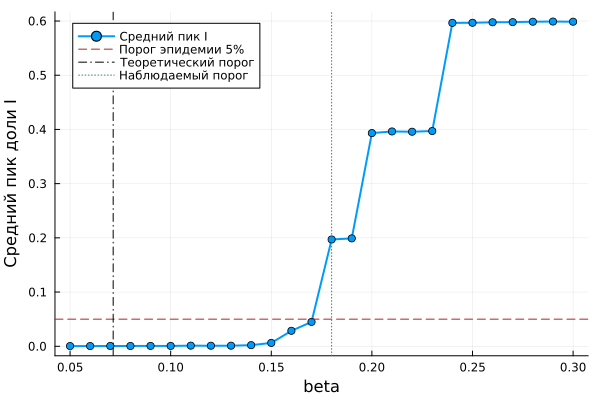

In [3]:
threshold_plot = plot_threshold_study(
    threshold_grouped;
    epidemic_threshold = threshold_summary.epidemic_threshold,
    theoretical_beta = threshold_summary.theoretical_beta,
    observed_beta = threshold_summary.observed_beta,
)
threshold_plot

## Выводы

1. Теоретический и наблюдаемый пороги не совпадают буквально.
2. В агентной стохастической модели вспышка должна не только начаться,
   но и превысить критерий `5%`.
3. Поэтому эмпирический порог получается выше классической оценки `R0 = 1`.